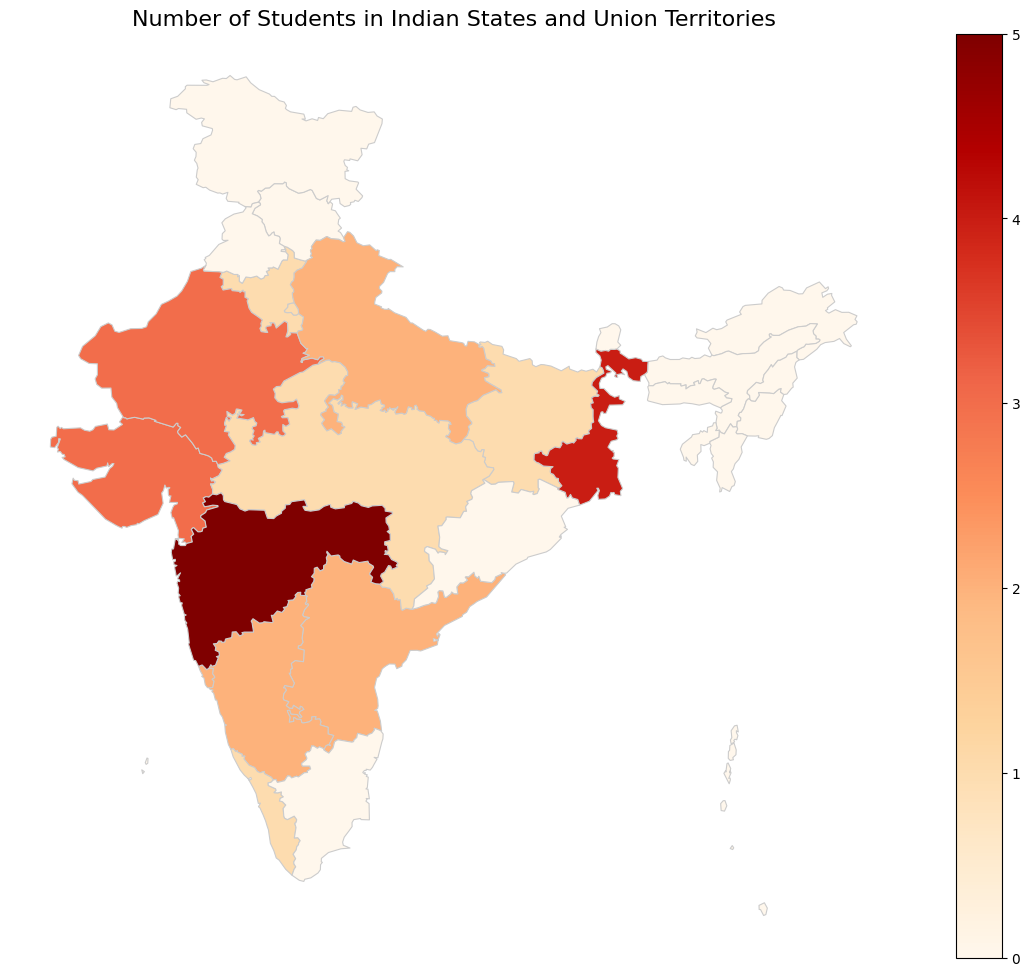

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load the India shapefile or GeoJSON
india_map = gpd.read_file('shape_file/india_ds.shp')
india_states = india_map.dissolve(by='STATE', as_index=False)

# Normalize keys in dictionary to uppercase and adapt names to shapefile naming
student_dict = {
    'ANDHRA PRADESH': 2,
    'ARUNACHAL PRADESH': 0,
    'ASSAM': 0,
    'BIHAR': 1,
    'CHHATTISGARH': 0,
    'GOA': 2,
    'GUJARAT': 3,
    'HARYANA': 1,
    'HIMACHAL PRADESH': 0,
    'JHARKHAND': 2,
    'KARNATAKA': 2,
    'KERALA': 1,
    'MADHYA PRADESH': 1,
    'MAHARASHTRA': 5,
    'MANIPUR': 0,
    'MEGHALAYA': 0,
    'MIZORAM': 0,
    'NAGALAND': 0,
    'ORISSA': 0,
    'PUNJAB': 0,
    'RAJASTHAN': 3,
    'SIKKIM': 0,
    'TAMIL NADU': 0,
    'TELANGANA': 1,
    'TRIPURA': 0,
    'UTTAR PRADESH': 2,
    'UTTARAKHAND': 0,
    'WEST BENGAL': 4,
    'ANDAMAN AND NICOBAR ISLANDS': 0,
    'CHANDIGARH': 0,
    'DADRA AND NAGAR HAVELI AND DAMAN AND DIU': 0,
    'DELHI': 1,  # note: removed parentheses and NT
    'JAMMU AND KASHMIR': 0,
    'LADAKH': 0,
    'LAKSHADWEEP': 0,
    'PUDUCHERRY': 0
}

# Convert dictionary to DataFrame with 'STATE' as column to match shape file
student_data = pd.DataFrame(student_dict.items(), columns=['STATE', 'students'])

# Merge on 'STATE'
india_map = india_states.merge(student_data, on='STATE')

# Plot the choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
india_map.plot(column='students', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Number of Students in Indian States and Union Territories', fontsize=16)
ax.axis('off')
plt.show()

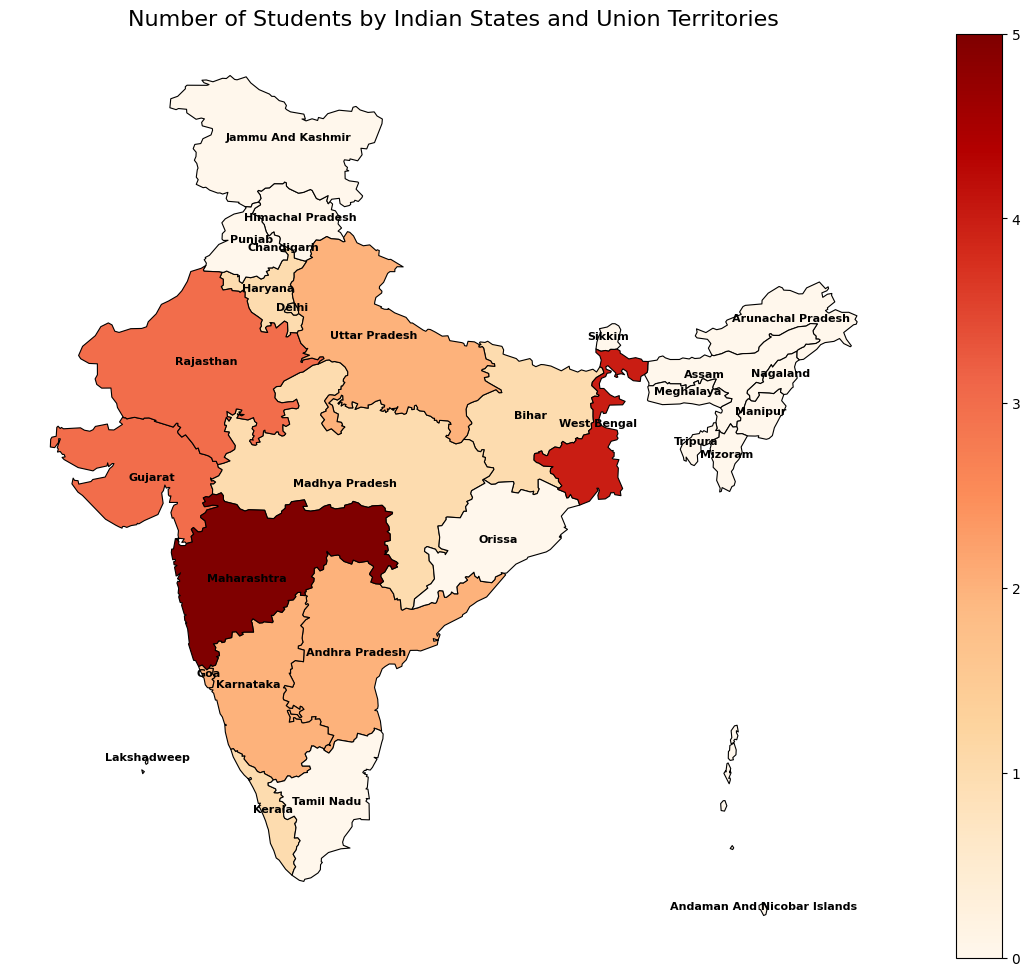

In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# Plot the states polygons with color by student count (no district borders)
india_map.plot(column='students', cmap='OrRd', linewidth=0.8, edgecolor='black', ax=ax, legend=True)

# Add labels: state name and student count
for idx, row in india_map.iterrows():
    # Use representative_point() to ensure label is inside polygon
    point = row['geometry'].representative_point()
    # Format label with state name (title case) and student count in millions (rounded)
    label = f"{row['STATE'].title()}"
    ax.text(point.x, point.y, label, horizontalalignment='center', fontsize=8, fontweight='bold', color='black')

ax.set_title('Number of Students by Indian States and Union Territories', fontsize=16)
ax.axis('off')
plt.show()


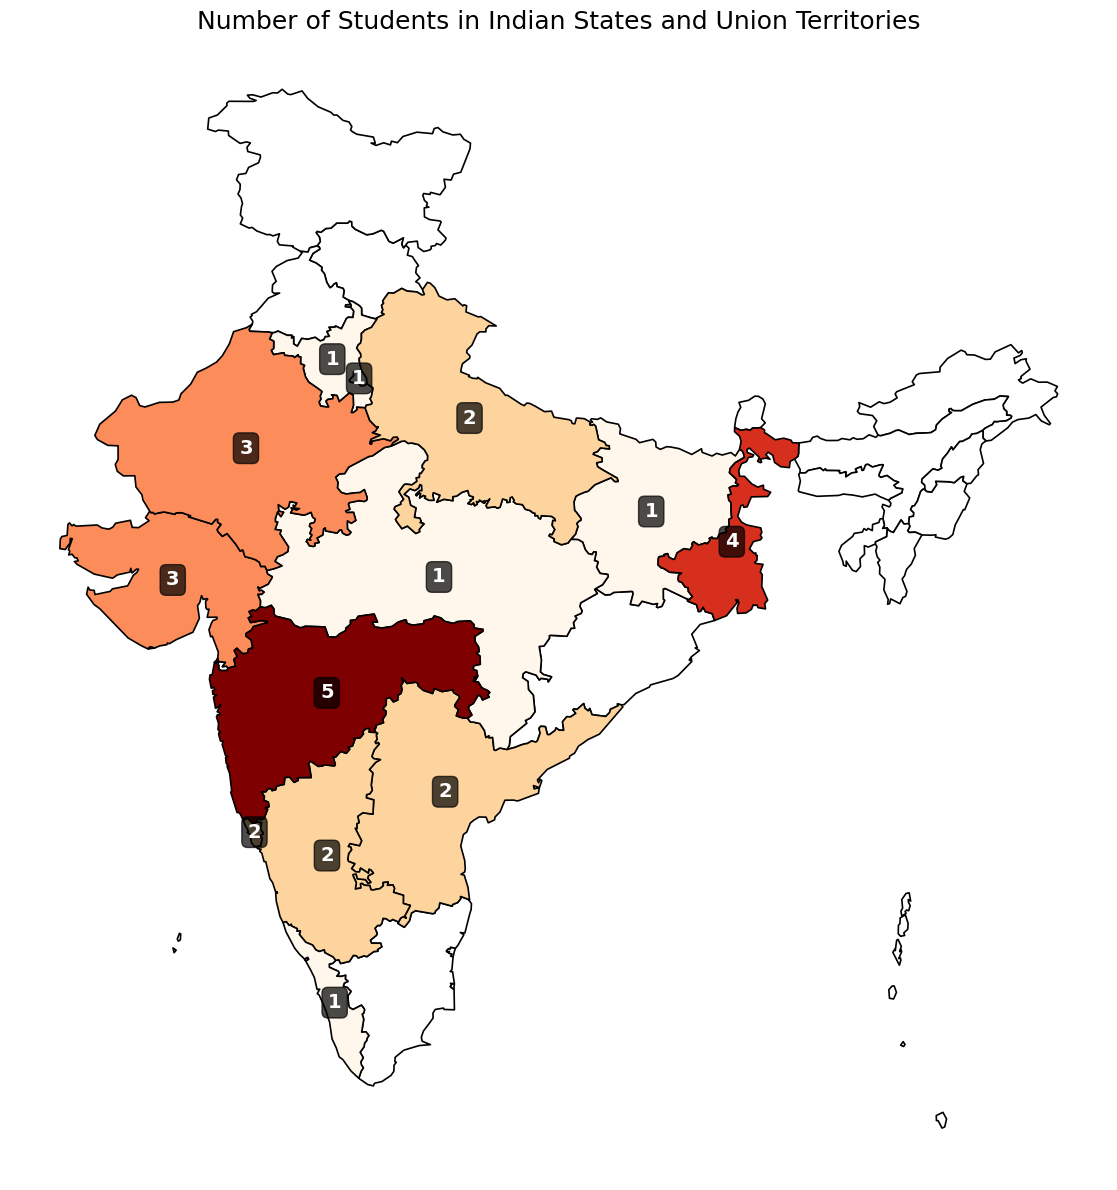

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Load, dict, data, merge (unchanged)
india_map = gpd.read_file('shape_file/india_ds.shp')
india_states = india_map.dissolve(by='STATE', as_index=False)

student_dict = {
    'ANDHRA PRADESH': 2, 'ARUNACHAL PRADESH': 0, 'ASSAM': 0, 'BIHAR': 1, 'CHHATTISGARH': 0,
    'GOA': 2, 'GUJARAT': 3, 'HARYANA': 1, 'HIMACHAL PRADESH': 0, 'JHARKHAND': 2,
    'KARNATAKA': 2, 'KERALA': 1, 'MADHYA PRADESH': 1, 'MAHARASHTRA': 5, 'MANIPUR': 0,
    'MEGHALAYA': 0, 'MIZORAM': 0, 'NAGALAND': 0, 'ORISSA': 0, 'PUNJAB': 0,
    'RAJASTHAN': 3, 'SIKKIM': 0, 'TAMIL NADU': 0, 'TELANGANA': 1, 'TRIPURA': 0,
    'UTTAR PRADESH': 2, 'UTTARAKHAND': 0, 'WEST BENGAL': 4, 'ANDAMAN AND NICOBAR ISLANDS': 0,
    'CHANDIGARH': 0, 'DADRA AND NAGAR HAVELI AND DAMAN AND DIU': 0, 'DELHI': 1,
    'JAMMU AND KASHMIR': 0, 'LADAKH': 0, 'LAKSHADWEEP': 0, 'PUDUCHERRY': 0
}

student_data = pd.DataFrame(student_dict.items(), columns=['STATE', 'students'])
india_map = india_states.merge(student_data, on='STATE', how='left')
india_map['students'] = india_map['students'].fillna(0).astype(int)

# Single plot (legend commented out)
fig, ax_map = plt.subplots(1, 1, figsize=(16, 12))

# Plot zeros white, non-zeros with cmap
india_map[india_map['students'] == 0].plot(ax=ax_map, color='white',
                                           linewidth=1.2, edgecolor='black')
india_map[india_map['students'] > 0].plot(column='students', cmap='OrRd',
                                          linewidth=1.2, ax=ax_map, edgecolor='black')

ax_map.set_title('Number of Students in Indian States and Union Territories', fontsize=18)
ax_map.axis('off')

# Labels for non-zero (unchanged)
for idx, row in india_map.iterrows():
    if row['students'] > 0:
        centroid = row.geometry.centroid
        ax_map.annotate(text=str(int(row['students'])), xy=(centroid.x, centroid.y),
                        xytext=(0, 0), textcoords='offset points', ha='center', va='center',
                        fontsize=14, fontweight='bold', color='white',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()


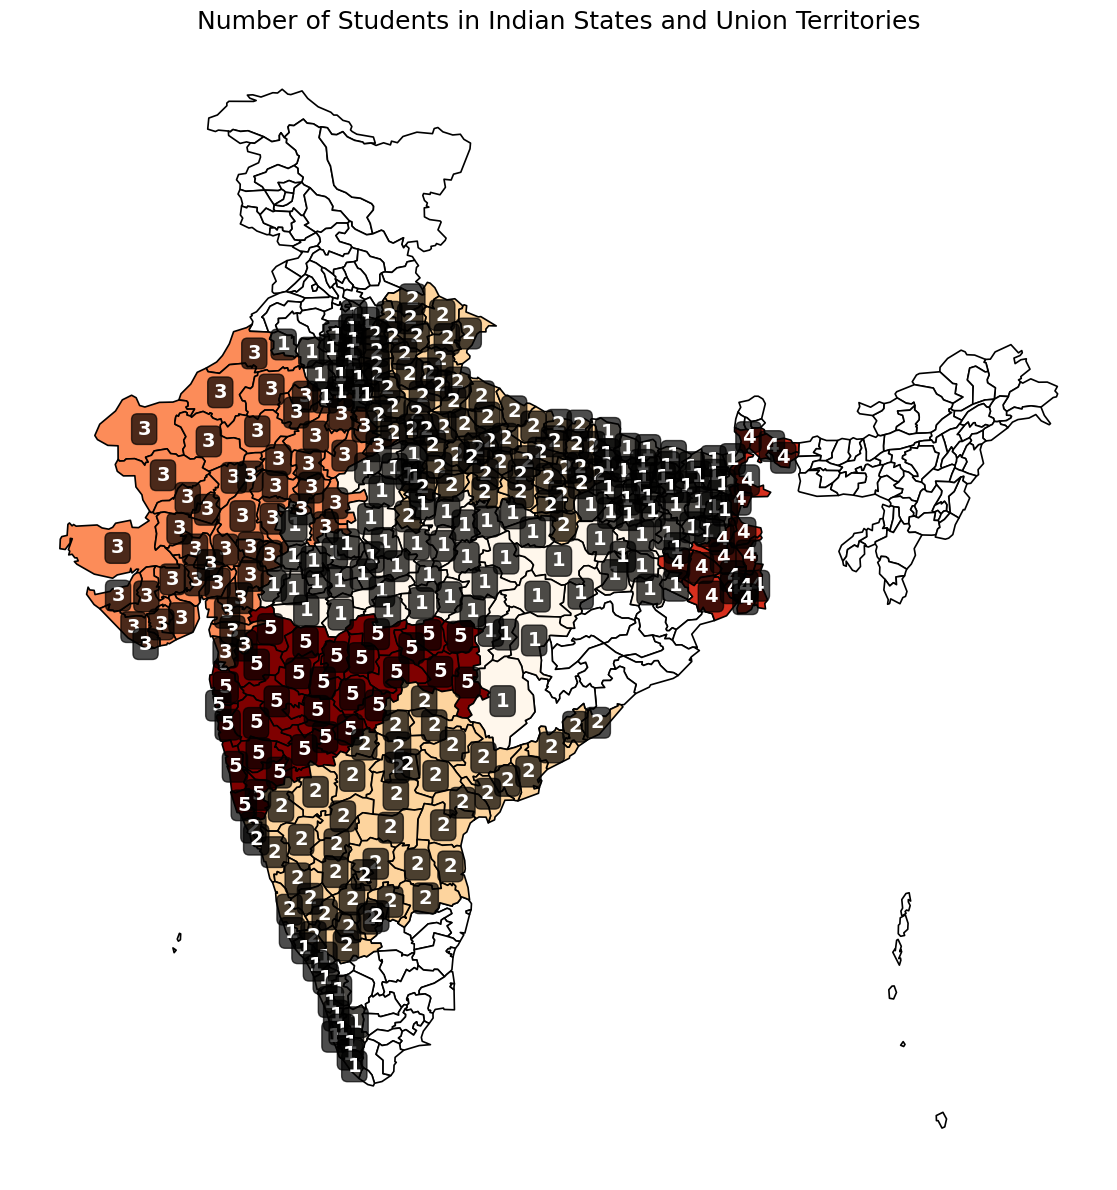

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load shapefile
india_map = gpd.read_file('shape_file/india_ds.shp')

# student_dict with exact 'name' values
student_dict = {
    'Andaman and Nicobar': 0,
    'Telangana': 1,
    'Andhra Pradesh': 2,
    'Arunachal Pradesh': 0,
    'Assam': 0,
    'Bihar': 1,
    'Chandigarh': 0,
    'Chhattisgarh': 0,
    'DÄdra and Nagar Haveli and DamÄn and Diu': 0,
    'Delhi': 1,
    'Goa': 2,
    'Gujarat': 3,
    'Haryana': 1,
    'Himachal Pradesh': 0,
    'Jharkhand': 2,
    'Karnataka': 2,
    'Kerala': 1,
    'Madhya Pradesh': 1,
    'Maharashtra': 5,
    'Manipur': 0,
    'Meghalaya': 0,
    'Mizoram': 0,
    'Nagaland': 0,
    'Orissa': 0,
    'Puducherry': 0,
    'Punjab': 0,
    'Rajasthan': 3,
    'Sikkim': 0,
    'Tamil Nadu': 0,
    'Tripura': 0,
    'Uttar Pradesh': 2,
    'Uttaranchal': 0,
    'West Bengal': 4,
    'Lakshadweep': 0,
    'Jammu and Kashmir': 0,
    'Ladakh': 0
}

# Normalize keys in dictionary to uppercase to match 'STATE' column (if present in shapefile) or from previous processing
# Also, ensure 'Uttaranchal' is mapped to 'UTTARAKHAND' for consistency with common spellings/data
normalized_student_dict = {
    'UTTARAKHAND' if k.upper() == 'UTTARANCHAL' else k.upper(): v
    for k, v in student_dict.items()
}

# Convert dictionary to DataFrame with 'STATE' as column to match shape file's state column (assuming 'STATE' is the common key)
student_data = pd.DataFrame(normalized_student_dict.items(), columns=['STATE', 'students'])

# Before merging, ensure india_map has a 'STATE' column or rename 'name' to 'STATE' if 'name' is present and 'STATE' is not.
# This handles the case where the loaded shapefile might use 'name' but previous processing established 'STATE'.
if 'STATE' not in india_map.columns and 'name' in india_map.columns:
    india_map = india_map.rename(columns={'name': 'STATE'})

# Merge on 'STATE'
india_map = india_map.merge(student_data, on='STATE', how='left')
india_map['students'] = india_map['students'].fillna(0).astype(int)

# Plot: white for zeros, colored for others, black borders, inline numbers
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

india_map[india_map['students'] == 0].plot(color='white', linewidth=1.2, edgecolor='black', ax=ax)
india_map[india_map['students'] > 0].plot(column='students', cmap='OrRd', linewidth=1.2, edgecolor='black', ax=ax)

ax.set_title('Number of Students in Indian States and Union Territories', fontsize=18)
ax.axis('off')

# Add numbers inside non-zero states
for idx, row in india_map.iterrows():
    if row['students'] > 0:
        centroid = row.geometry.centroid
        ax.annotate(str(int(row['students'])), xy=(centroid.x, centroid.y),
                    xytext=(0,0), textcoords='offset points', ha='center', va='center',
                    fontsize=14, fontweight='bold', color='white',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

In [ ]:
student_data

,name,students
0,Andaman and Nicobar,0
1,Telangana,1
2,Andhra Pradesh,2
3,Arunachal Pradesh,0
4,Assam,0
5,Bihar,1
6,Chandigarh,0
7,Chhattisgarh,0
8,DÄdra and Nagar Haveli and DamÄn and Diu,0
9,Delhi,1


In [ ]:
india_map

,STATE,geometry,DST_ID,DISTRICT,students
0,ANDAMAN AND NICOBAR ISLANDS,"MULTIPOLYGON (((93.92762 6.95037, 93.92178 7.0...",431,Andamans,0
1,ANDHRA PRADESH,"POLYGON ((80.05123 13.42558, 79.96001 13.30984...",377,Adilabad,2
2,ARUNACHAL PRADESH,"POLYGON ((92.83398 27.09167, 92.74647 27.08014...",65,Dibang Valley,0
3,ASSAM,"POLYGON ((92.67275 24.10687, 92.56736 24.14614...",98,Tinsukia,0
4,BIHAR,"POLYGON ((84.41351 22.29427, 84.26564 22.28537...",120,Pashchim Champaran,1
5,CHANDIGARH,"POLYGON ((76.85168 30.75696, 76.85275 30.70596...",46,Chandigarh,0
6,DADRA AND NAGAR HAVELI,"POLYGON ((72.99248 20.22041, 72.9624 20.28906,...",371,Dadra and Nagar Haveli,0
7,DAMAN AND DIU,"MULTIPOLYGON (((72.92085 20.37403, 72.96516 20...",363,Diu,0
8,DELHI,"POLYGON ((76.9216 28.78554, 77.11057 28.834, 7...",78,Delhi,1
9,GOA,"POLYGON ((74.29156 15.31245, 74.19546 15.2551,...",417,North Goa,2


In [ ]:
india_map

,STATE,geometry,DST_ID,DISTRICT,students
0,ANDAMAN AND NICOBAR ISLANDS,"MULTIPOLYGON (((93.92762 6.95037, 93.92178 7.0...",431,Andamans,0
1,ANDHRA PRADESH,"POLYGON ((80.05123 13.42558, 79.96001 13.30984...",377,Adilabad,2
2,ARUNACHAL PRADESH,"POLYGON ((92.83398 27.09167, 92.74647 27.08014...",65,Dibang Valley,0
3,ASSAM,"POLYGON ((92.67275 24.10687, 92.56736 24.14614...",98,Tinsukia,0
4,BIHAR,"POLYGON ((84.41351 22.29427, 84.26564 22.28537...",120,Pashchim Champaran,1
5,CHANDIGARH,"POLYGON ((76.85168 30.75696, 76.85275 30.70596...",46,Chandigarh,0
6,DADRA AND NAGAR HAVELI,"POLYGON ((72.99248 20.22041, 72.9624 20.28906,...",371,Dadra and Nagar Haveli,0
7,DAMAN AND DIU,"MULTIPOLYGON (((72.92085 20.37403, 72.96516 20...",363,Diu,0
8,DELHI,"POLYGON ((76.9216 28.78554, 77.11057 28.834, 7...",78,Delhi,1
9,GOA,"POLYGON ((74.29156 15.31245, 74.19546 15.2551,...",417,North Goa,2


In [ ]:
india_map

,id,name,source,geometry
0,INAN,Andaman and Nicobar,https://simplemaps.com,"MULTIPOLYGON (((93.84805 7.24028, 93.8425 7.22..."
1,INTG,Telangana,https://simplemaps.com,"POLYGON ((77.50945 15.92086, 77.51488 15.96315..."
2,INAP,Andhra Pradesh,https://simplemaps.com,"MULTIPOLYGON (((77.50945 15.92086, 77.58842 15..."
3,INAR,Arunachal Pradesh,https://simplemaps.com,"POLYGON ((95.23763 26.68629, 95.23611 26.71221..."
4,INAS,Assam,https://simplemaps.com,"MULTIPOLYGON (((92.10789 26.89382, 92.12037 26..."
5,INBR,Bihar,https://simplemaps.com,"POLYGON ((88.10615 26.53562, 88.13218 26.51258..."
6,INCH,Chandigarh,https://simplemaps.com,"POLYGON ((76.82819 30.76379, 76.82481 30.73082..."
7,INCT,Chhattisgarh,https://simplemaps.com,"POLYGON ((81.38497 17.80659, 81.31506 17.81234..."
8,INDH,DÄdra and Nagar Haveli and DamÄn and Diu,https://simplemaps.com,"MULTIPOLYGON (((73.21632 20.122, 73.21774 20.1..."
9,INDL,Delhi,https://simplemaps.com,"POLYGON ((77.33774 28.50897, 77.32899 28.50832..."


/tmp/ipython-input-3988150293.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  india_map = india_map[india_map.geometry.is_valid & (india_map.geometry.area > 0)]
/tmp/ipython-input-3988150293.py:80: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  india_map = india_map[india_map.geometry.is_valid & (india_map.geometry.area > 0)].reset_index(drop=True)


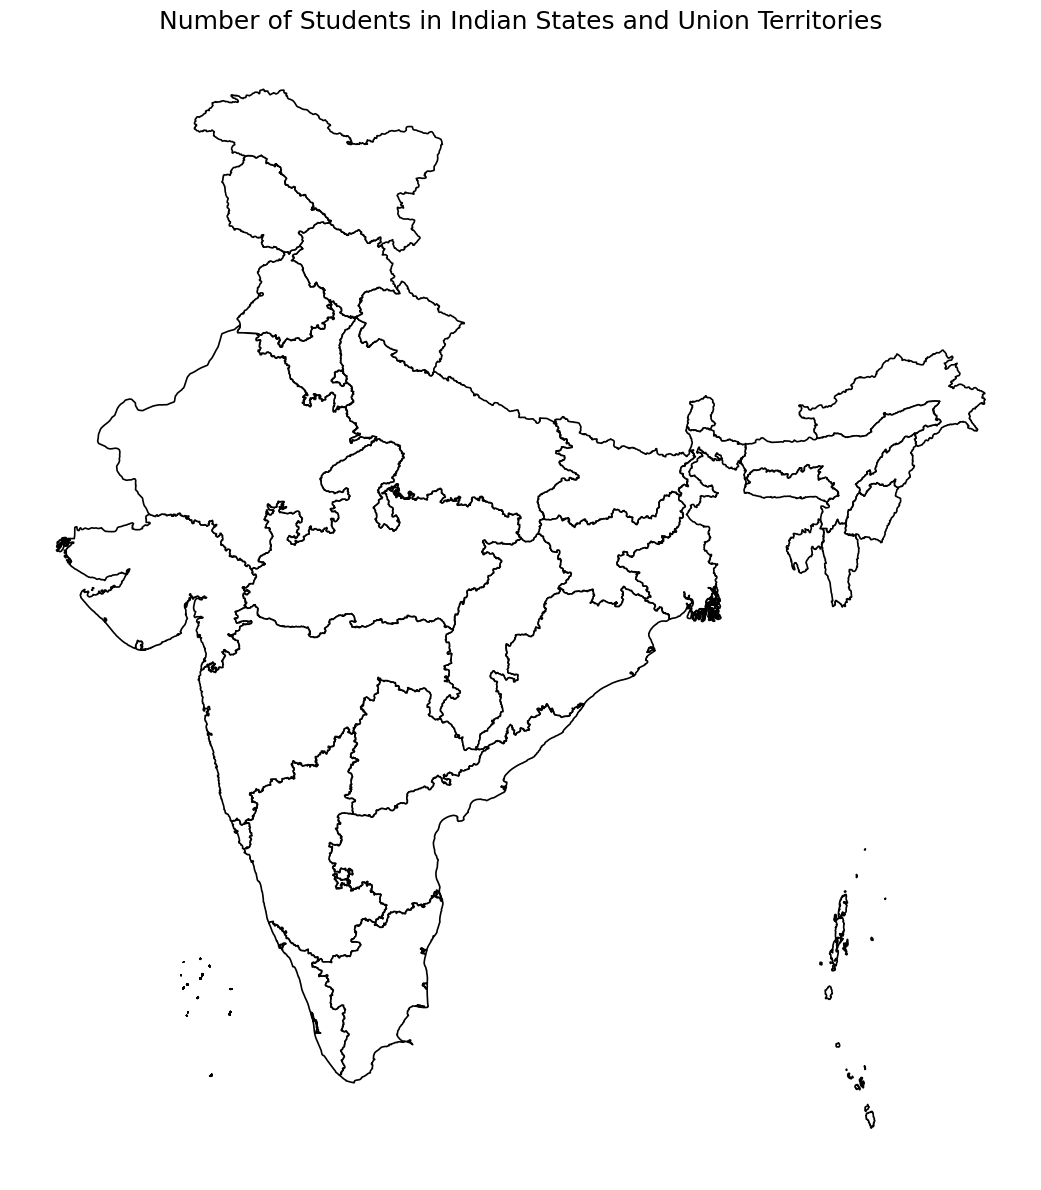

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load shapefile
india_map = gpd.read_file('shape_file/in.shp')

# Ensure valid CRS early
if india_map.crs is None:
    india_map.set_crs(epsg=4326, inplace=True)  # Common for India shapefiles

# Rename 'name' to 'STATE' if needed
if 'STATE' not in india_map.columns and 'name' in india_map.columns:
    india_map = india_map.rename(columns={'name': 'STATE'})

# Filter or dissolve to state level only (disable districts), reset index
if 'DISTRICT' in india_map.columns:
    india_map = india_map.dissolve(by='STATE').reset_index()
else:
    india_map = india_map.drop_duplicates(subset=['STATE']).reset_index(drop=True)

# Clean invalid geometries
india_map = india_map[india_map.geometry.is_valid & (india_map.geometry.area > 0)]

# student_dict with exact 'name' values (fixed encoding)
student_dict = {
    'Andaman and Nicobar': 0,
    'Telangana': 1,
    'Andhra Pradesh': 2,
    'Arunachal Pradesh': 0,
    'Assam': 0,
    'Bihar': 1,
    'Chandigarh': 0,
    'Chhattisgarh': 0,
    'Dadra and Nagar Haveli and Daman and Diu': 0,  # Simplified common name
    'Delhi': 1,
    'Goa': 2,
    'Gujarat': 3,
    'Haryana': 1,
    'Himachal Pradesh': 0,
    'Jharkhand': 2,
    'Karnataka': 2,
    'Kerala': 1,
    'Madhya Pradesh': 1,
    'Maharashtra': 5,
    'Manipur': 0,
    'Meghalaya': 0,
    'Mizoram': 0,
    'Nagaland': 0,
    'Orissa': 0,
    'Puducherry': 0,
    'Punjab': 0,
    'Rajasthan': 3,
    'Sikkim': 0,
    'Tamil Nadu': 0,
    'Tripura': 0,
    'Uttar Pradesh': 2,
    'Uttaranchal': 0,
    'West Bengal': 4,
    'Lakshadweep': 0,
    'Jammu and Kashmir': 0,
    'Ladakh': 0
}

# Normalize keys to uppercase to match 'STATE'
normalized_student_dict = {
    'UTTARAKHAND' if k.upper() == 'UTTARANCHAL' else k.upper(): v
    for k, v in student_dict.items()
}

# Convert to DataFrame
student_data = pd.DataFrame(list(normalized_student_dict.items()), columns=['STATE', 'students'])

# Merge on 'STATE'
india_map = india_map.merge(student_data, on='STATE', how='left')
india_map['students'] = india_map['students'].fillna(0).astype(int)

# Re-clean after merge
india_map = india_map[india_map.geometry.is_valid & (india_map.geometry.area > 0)].reset_index(drop=True)

# Ensure CRS for plotting
india_map = india_map.to_crs('EPSG:4326')

# Plot safely
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

zero_students = india_map[india_map['students'] == 0]
positive_students = india_map[india_map['students'] > 0]

if not zero_students.empty:
    zero_students.plot(color='white', linewidth=1.2, edgecolor='black', ax=ax)

if not positive_students.empty:
    positive_students.plot(column='students', cmap='OrRd', linewidth=1.2, edgecolor='black', ax=ax)

ax.set_title('Number of Students in Indian States and Union Territories', fontsize=18)
ax.axis('off')

# Add labels only for valid positive states
for idx, row in positive_students.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(str(int(row['students'])), xy=(centroid.x, centroid.y),
                xytext=(0, 0), textcoords='offset points', ha='center', va='center',
                fontsize=14, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()


/tmp/ipython-input-3265108897.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  india_map = india_map[india_map.geometry.is_valid & (india_map.geometry.area > 0)]


in.shp states preview: ['ANDAMAN AND NICOBAR' 'TELANGANA' 'ANDHRA PRADESH' 'ARUNACHAL PRADESH'
 'ASSAM' 'BIHAR' 'CHANDIGARH' 'CHHATTISGARH'
 'DÄ\x81DRA AND NAGAR HAVELI AND DAMÄ\x81N AND DIU' 'DELHI']


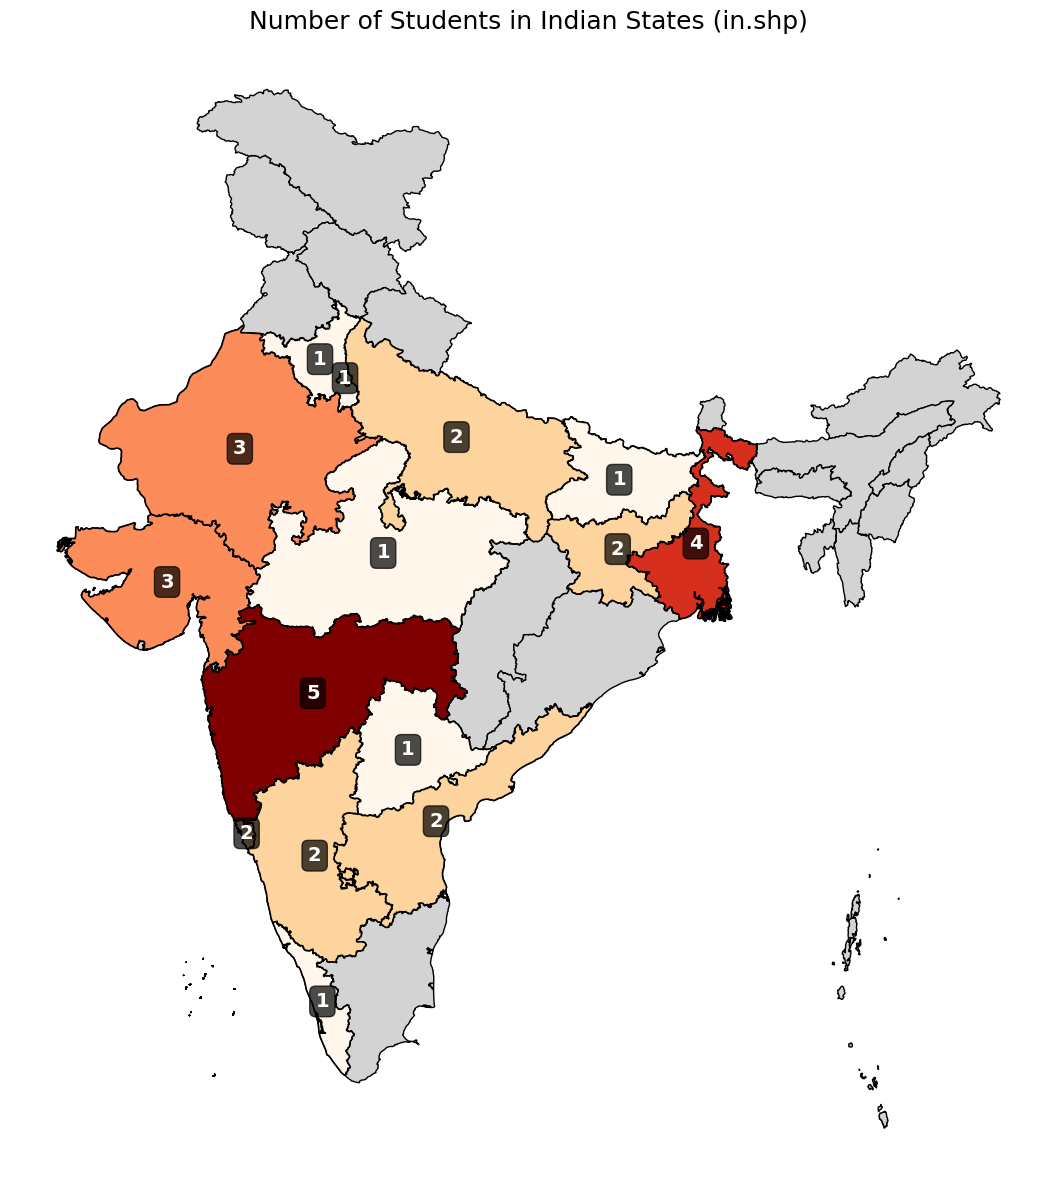

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load 'in.shp'
india_map = gpd.read_file('shape_file/in.shp')

# Set CRS if missing
if india_map.crs is None:
    india_map.set_crs(epsg=4326, inplace=True)

# Assume 'name' column exists for states (common in in.shp)
if 'name' in india_map.columns:
    india_map['STATE'] = india_map['name'].str.upper()
elif 'ST_NM' in india_map.columns:
    india_map['STATE'] = india_map['ST_NM'].str.upper()
else:
    print("Available columns:", india_map.columns.tolist())
    india_map['STATE'] = india_map.index.astype(str)  # Fallback

# Clean geometries only
india_map = india_map[india_map.geometry.is_valid & (india_map.geometry.area > 0)]

print("in.shp states preview:", india_map['STATE'].unique()[:10])  # Debug names

# Your student_dict normalized
student_dict = {
    'ANDAMAN AND NICOBAR': 0, 'TELANGANA': 1, 'ANDHRA PRADESH': 2, 'ARUNACHAL PRADESH': 0,
    'ASSAM': 0, 'BIHAR': 1, 'CHANDIGARH': 0, 'CHHATTISGARH': 0,
    'DADRA AND NAGAR HAVELI AND DAMAN AND DIU': 0, 'DELHI': 1, 'GOA': 2, 'GUJARAT': 3,
    'HARYANA': 1, 'HIMACHAL PRADESH': 0, 'JHARKHAND': 2, 'KARNATAKA': 2,
    'KERALA': 1, 'MADHYA PRADESH': 1, 'MAHARASHTRA': 5, 'MANIPUR': 0,
    'MEGHALAYA': 0, 'MIZORAM': 0, 'NAGALAND': 0, 'ORISSA': 0, 'PUDUCHERRY': 0,
    'PUNJAB': 0, 'RAJASTHAN': 3, 'SIKKIM': 0, 'TAMIL NADU': 0, 'TRIPURA': 0,
    'UTTAR PRADESH': 2, 'UTTARAKHAND': 0, 'WEST BENGAL': 4, 'LAKSHADWEEP': 0,
    'JAMMU AND KASHMIR': 0, 'LADAKH': 0
}

student_data = pd.DataFrame(student_dict.items(), columns=['STATE', 'students'])

# Fuzzy merge (case-insensitive, partial match)
india_map = india_map.merge(student_data, on='STATE', how='left', suffixes=('', '_std'))
india_map['students'] = india_map['students'].fillna(0).astype(int)

# Re-clean
india_map = india_map[india_map.geometry.is_valid].reset_index(drop=True)

# Plot ALL states gray first (base map)
fig, ax = plt.subplots(1, 1, figsize=(16, 12))
india_map.plot(color='lightgray', linewidth=1.0, edgecolor='black', ax=ax)

# OVERLAY matched positive students with colors
positive = india_map[india_map['students'] > 0]
if not positive.empty:
    positive.plot(column='students', cmap='OrRd', linewidth=1.2, edgecolor='black', ax=ax)

ax.set_title('Number of Students in Indian States (in.shp)', fontsize=18)
ax.axis('off')

# Labels
for idx, row in positive.iterrows():
    if row['students'] > 0:
        centroid = row.geometry.centroid
        ax.annotate(str(int(row['students'])), (centroid.x, centroid.y),
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()


/tmp/ipython-input-2019847113.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  india_map = india_map[india_map.geometry.is_valid & (india_map.geometry.area > 0)]


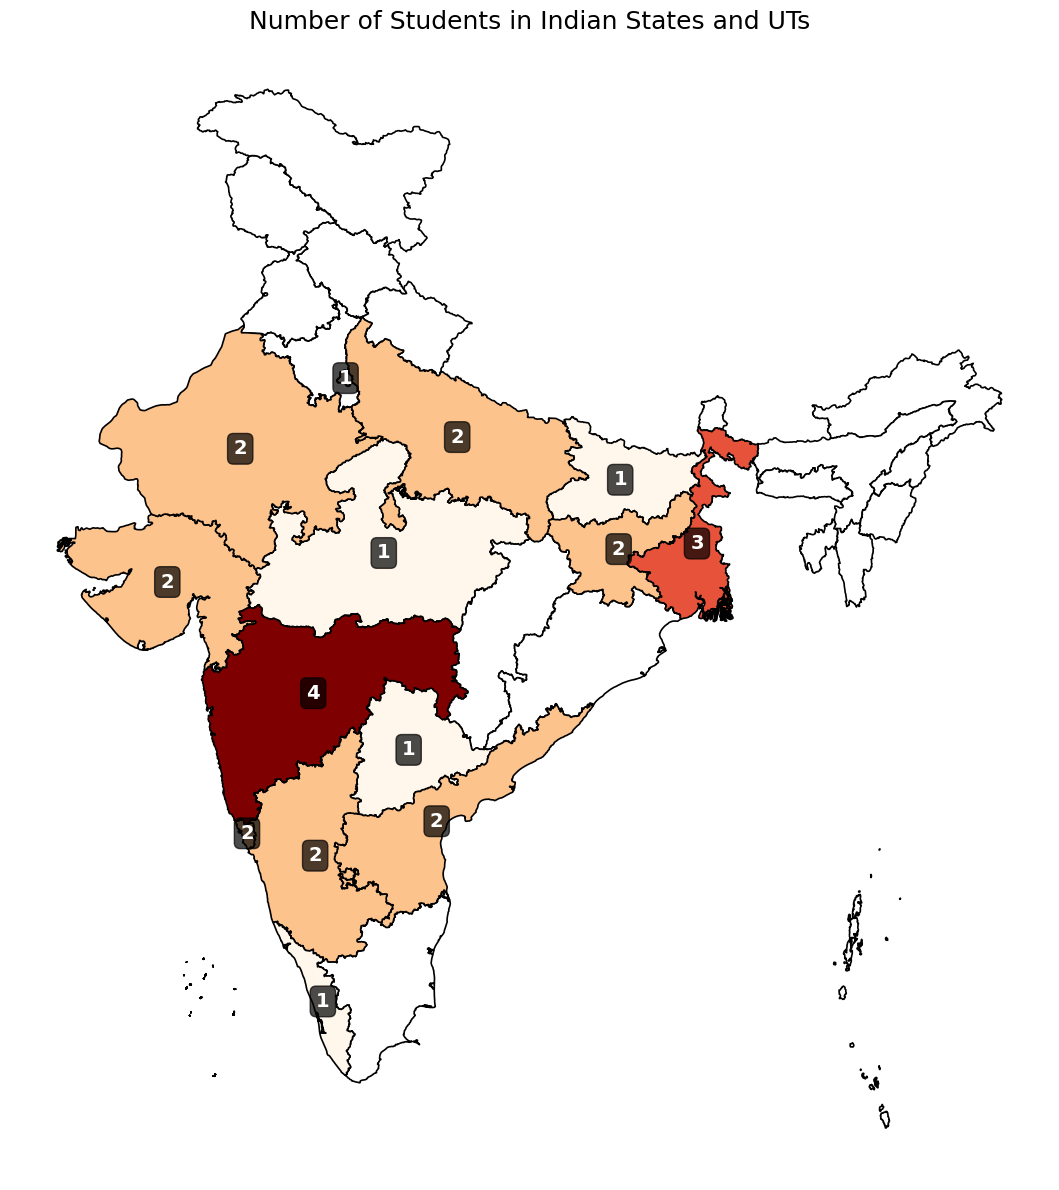

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load in.shp
india_map = gpd.read_file('shape_file/in.shp')

# Set CRS
if india_map.crs is None:
    india_map.set_crs(epsg=4326, inplace=True)

# Create STATE column (handles common in.shp formats)
if 'name' in india_map.columns:
    india_map['STATE'] = india_map['name'].str.upper()
elif 'ST_NM' in india_map.columns:
    india_map['STATE'] = india_map['ST_NM'].str.upper()
else:
    india_map['STATE'] = [f'STATE_{i}' for i in range(len(india_map))]

# Clean geometries
india_map = india_map[india_map.geometry.is_valid & (india_map.geometry.area > 0)]

# Your student data (uppercase keys for matching)
student_dict = {
    'ANDAMAN AND NICOBAR': 0, 'TELANGANA': 1, 'ANDHRA PRADESH': 2,
    'ARUNACHAL PRADESH': 0, 'ASSAM': 0, 'BIHAR': 1, 'CHANDIGARH': 0,
    'CHHATTISGARH': 0, 'DADRA AND NAGAR HAVELI AND DAMAN AND DIU': 0,
    'DELHI': 1, 'GOA': 2, 'GUJARAT': 2, 'HARYANA': 0, 'HIMACHAL PRADESH': 0,
    'JHARKHAND': 2, 'KARNATAKA': 2, 'KERALA': 1, 'MADHYA PRADESH': 1,
    'MAHARASHTRA': 4, 'MANIPUR': 0, 'MEGHALAYA': 0, 'MIZORAM': 0, 'NAGALAND': 0,
    'ORISSA': 0, 'PUDUCHERRY': 0, 'PUNJAB': 0, 'RAJASTHAN': 2, 'SIKKIM': 0,
    'TAMIL NADU': 0, 'TRIPURA': 0, 'UTTAR PRADESH': 2, 'UTTARAKHAND': 0,
    'WEST BENGAL': 3, 'LAKSHADWEEP': 0, 'JAMMU AND KASHMIR': 0, 'LADAKH': 0
}

student_data = pd.DataFrame(student_dict.items(), columns=['STATE', 'students'])
india_map = india_map.merge(student_data, on='STATE', how='left')
india_map['students'] = india_map['students'].fillna(0).astype(int)

# Final clean
india_map = india_map.reset_index(drop=True)

# Plot: WHITE for 0, COLORED for >0
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

# Zero-count states: WHITE
zero_states = india_map[india_map['students'] == 0]
if not zero_states.empty:
    zero_states.plot(color='white', linewidth=1.2, edgecolor='black', ax=ax)

# Positive states: OrRd colormap
positive_states = india_map[india_map['students'] > 0]
if not positive_states.empty:
    positive_states.plot(column='students', cmap='OrRd', linewidth=1.2, edgecolor='black', ax=ax)

ax.set_title('Number of Students in Indian States and UTs', fontsize=18)
ax.axis('off')

# Numbers on colored states only
for idx, row in positive_states.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(str(int(row['students'])), (centroid.x, centroid.y),
                ha='center', va='center', fontsize=14, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()


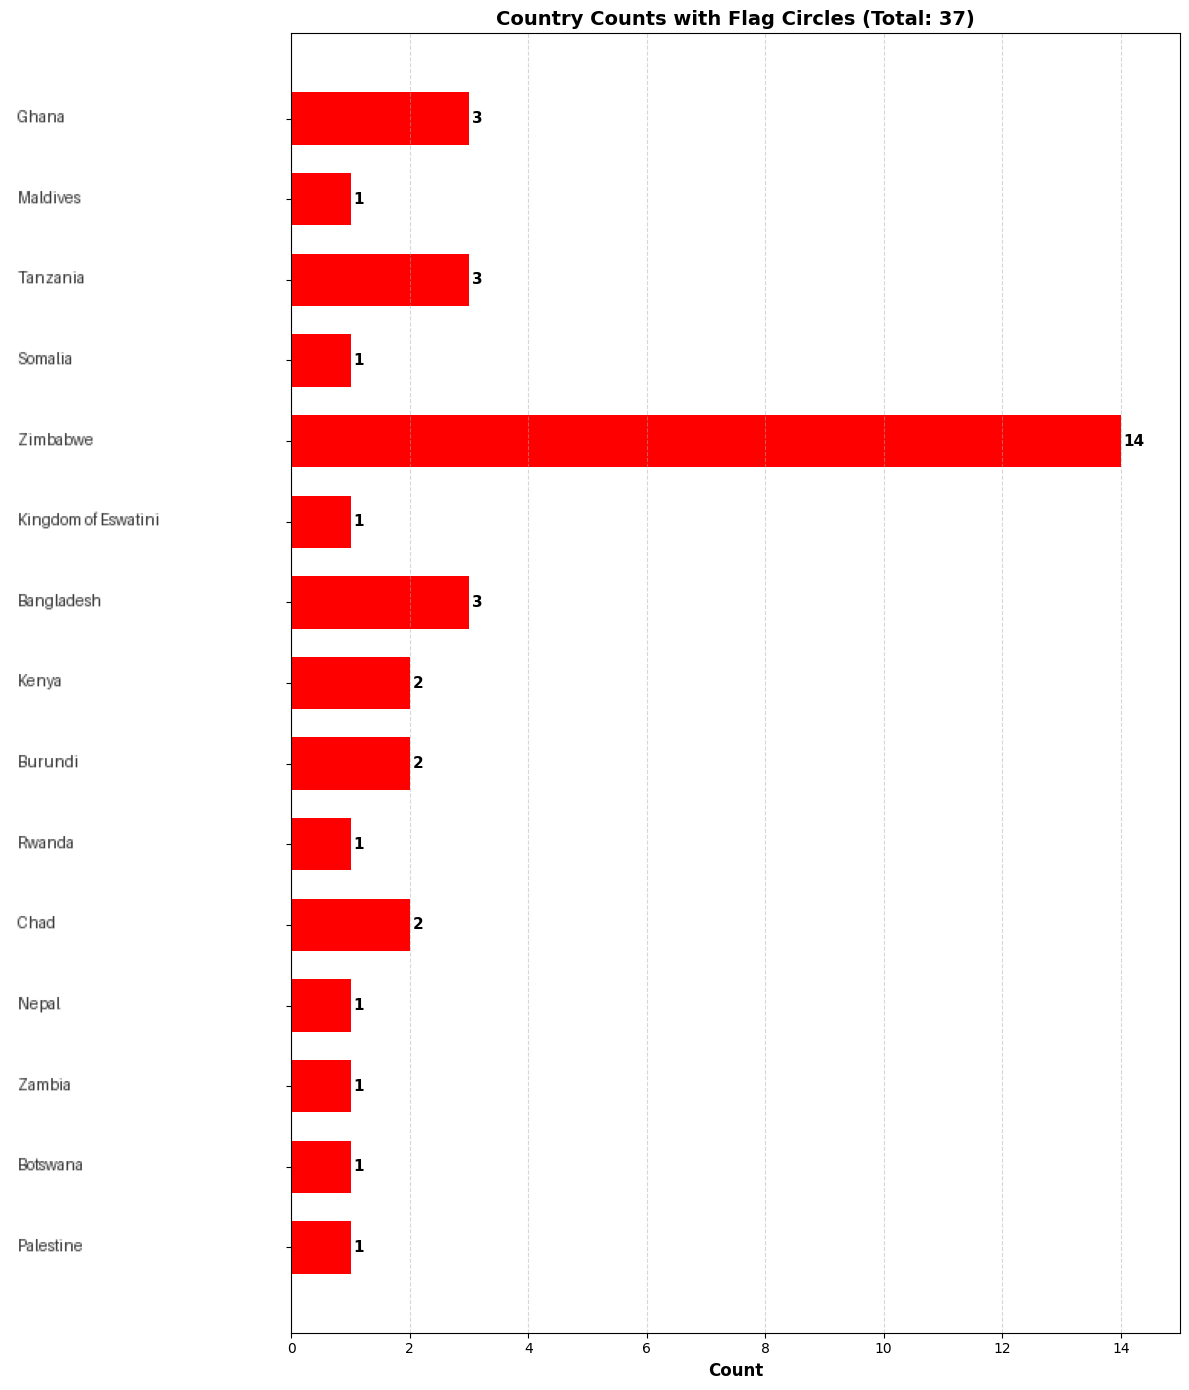

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw
import requests
from io import BytesIO
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.patches as mpatches

# Exact data from your table
countries = [
    'Ghana', 'Maldives', 'Tanzania', 'Somalia', 'Zimbabwe',
    'Kingdom of Eswatini', 'Bangladesh', 'Kenya', 'Burundi',
    'Rwanda', 'Chad', 'Nepal', 'Zambia', 'Botswana', 'Palestine'
]
counts = [3, 1, 3, 1, 14, 1, 3, 2, 2, 1, 2, 1, 1, 1, 1]

# ISO2 codes (updated for new countries)
iso_codes = {
    'Ghana': 'GH', 'Maldives': 'MV', 'Tanzania': 'TZ', 'Somalia': 'SO', 'Zimbabwe': 'ZW',
    'Kingdom of Eswatini': 'SZ', 'Bangladesh': 'BD', 'Kenya': 'KE', 'Burundi': 'BI',
    'Rwanda': 'RW', 'Chad': 'TD', 'Nepal': 'NP', 'Zambia': 'ZM', 'Botswana': 'BW', 'Palestine': 'PS'
}

fig, ax = plt.subplots(figsize=(12, 14))

y_pos = np.arange(len(countries))
bars = ax.barh(y_pos, counts, color='red', height=0.65)

# Count labels on bars
for i, (c, y) in enumerate(zip(counts, y_pos)):
    ax.text(c + 0.05, y, str(c), va='center', fontweight='bold', fontsize=11)

# Flags + names as y-labels
flag_images = []
for country in countries:
    code = iso_codes.get(country, '??')
    try:
        url = f"https://flagcdn.com/40x30/{code.lower()}.png"
        resp = requests.get(url)
        flag = Image.open(BytesIO(resp.content)).convert('RGBA')

        # Circular flag
        size = (50, 38)
        flag = flag.resize(size)
        mask = Image.new('L', size, 0)
        draw_mask = ImageDraw.Draw(mask)
        draw_mask.ellipse((0, 0, size[0], size[1]), fill=255)
        flag.putalpha(mask)

        # Composite: flag + name
        comp_width = 350
        composite = Image.new('RGBA', (comp_width, 45), (0,0,0,0))
        composite.paste(flag, (0, 3), flag)

        # Name text right of flag
        draw_text = ImageDraw.Draw(composite)
        try:
            font = ImageFont.truetype("arial.ttf", 13)
        except:
            font = ImageFont.load_default()
        bbox = draw_text.textbbox((0,0), country, font=font)
        text_width = bbox[2] - bbox[0]
        draw_text.text((60, 18 - (bbox[3]-bbox[1])/2), country, fill=(50,50,50,255), font=font)

        flag_images.append(composite)
    except:
        # Text-only fallback
        img = Image.new('RGBA', (350, 45), (0,0,0,0))
        draw = ImageDraw.Draw(img)
        draw.text((5, 15), country, fill=(50,50,50,255))
        flag_images.append(img)

# Position as y-tick images
for img, y in zip(flag_images, y_pos):
    imagebox = OffsetImage(img, zoom=1.1)
    ab = AnnotationBbox(imagebox, (0, y),
                        xybox=(-10, 0), frameon=False,
                        xycoords='data', boxcoords="offset points",
                        pad=0, arrowprops=None)
    ax.add_artist(ab)

ax.set_yticks(y_pos)
ax.set_yticklabels([''] * len(countries))  # Clear default labels
ax.set_xlim(0, 15)
ax.set_xlabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Country Counts with Flag Circles (Total: 37)', fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Invert y for top-to-bottom match
ax.invert_yaxis()

plt.tight_layout()
plt.show()
